# Extraction Quality Testing

This notebook checks the **quality of your extracted slide data** — after extraction and cleaning are done.

**What this does, in simple words:**
1. Loads all the extracted JSON files from your output folder
2. Runs a checklist on every slide (empty text? empty chart? empty table? etc.)
3. Gives every slide a "risk score" — higher score = more likely something went wrong
4. Shows you charts + tables so you can see the worst slides first
5. Saves a short review list you can manually check

Run the cells in order, top to bottom.

## Step 0 — Setup

Point `PROJECT_ROOT` at the folder that contains your `extraction/` package (the one from the pipeline we built), and `OUTPUT_DIR` at the folder holding your cleaned, extracted `.json` files.

In [11]:
import sys
from pathlib import Path

# EDIT THESE TWO PATHS FOR YOUR MACHINE
PROJECT_ROOT = "/Users/rohit/Documents/Git/Enterprise_RAG_Pipeline/src"
OUTPUT_DIR = "/Users/rohit/Documents/Git/Enterprise_RAG_Pipeline/data/processed"   # folder containing your extracted+cleaned .json files

sys.path.insert(0, PROJECT_ROOT)

# quick sanity check before we go further
assert Path(PROJECT_ROOT, "extraction").exists(), (
    "Can't find the extraction/ package at PROJECT_ROOT — update the path above."
)
assert Path(OUTPUT_DIR).exists(), (
    "Can't find OUTPUT_DIR — update the path above to where your .json files live."
)
print("Setup OK.")

Setup OK.


In [12]:
# If pandas / matplotlib aren't installed yet, uncomment the next line and run it once:
# %pip install pandas matplotlib --quiet

import pandas as pd
import matplotlib.pyplot as plt

from extraction.qa.report import (
    evaluate_directory,
    write_report_csv,
    build_review_sample,
    print_summary,
)

## Step 1 — Run the quality checklist on every slide

This opens every `.json` file in `OUTPUT_DIR`, runs the 5 checks on every slide inside it
(near-empty text, empty chart, empty table, image with no OCR text, mostly-empty-decoration slide),
and gives each slide a risk score.

In [13]:
results = evaluate_directory(OUTPUT_DIR)
print_summary(results)

Total slides evaluated: 1885
Flagged (risk_score > 0): 536 (28.4%)

Flag breakdown:
  image_ocr_found_nothing: 536


## Step 2 — Turn results into a table you can actually look at

This converts the results into a normal spreadsheet-style table (a pandas DataFrame),
sorted from most suspicious slide to least suspicious.

In [14]:
rows = [{
    "document_id": r.document_id,
    "page_number": r.page_number,
    "risk_score": r.risk_score,
    "char_count": r.char_count,
    "object_count": r.object_count,
    "flags": "; ".join(r.flags),
} for r in results]

df = pd.DataFrame(rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
df.head(20)  # top 20 worst slides

,document_id,page_number,risk_score,char_count,object_count,flags
0,ARDC_Pidapalooza_Simons_Duncan_2020,1,3,108,3,image_ocr_found_nothing(x1)
1,Module4-FAIR-Presentation,14,3,405,6,image_ocr_found_nothing(x2)
2,Town_Hall_Ethics_AI_ML,17,3,382,4,image_ocr_found_nothing(x2)
3,Town_Hall_Ethics_AI_ML,18,3,215,3,image_ocr_found_nothing(x1)
4,Town_Hall_Ethics_AI_ML,24,3,279,3,image_ocr_found_nothing(x1)
5,Module4-FAIR-Presentation,1,3,241,5,image_ocr_found_nothing(x2)
6,Module4-FAIR-Presentation,3,3,119,4,image_ocr_found_nothing(x1)
7,Module4-FAIR-Presentation,4,3,212,7,image_ocr_found_nothing(x1)
8,Module4-FAIR-Presentation,7,3,341,3,image_ocr_found_nothing(x1)
9,Module4-FAIR-Presentation,8,3,357,3,image_ocr_found_nothing(x1)


## Step 3 — Chart: how many slides are flagged vs clean?

A quick visual gut-check — what fraction of your 1000 slides actually got flagged.

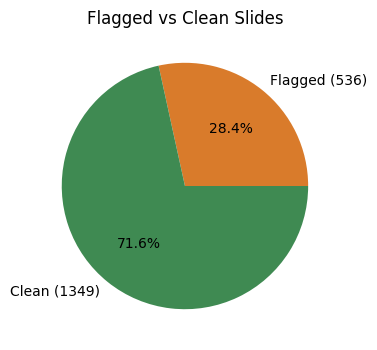

In [15]:
flagged_count = (df["risk_score"] > 0).sum()
clean_count = (df["risk_score"] == 0).sum()

plt.figure(figsize=(4, 4))
plt.pie(
    [flagged_count, clean_count],
    labels=[f"Flagged ({flagged_count})", f"Clean ({clean_count})"],
    autopct="%1.1f%%",
    colors=["#d97b2b", "#3f8a52"],
)
plt.title("Flagged vs Clean Slides")
plt.show()

## Step 4 — Chart: which red flags are most common?

This tells you WHERE your extraction is weakest overall — e.g. if "chart_extraction_empty"
is your biggest bar, charts are your main problem area, not tables or text.

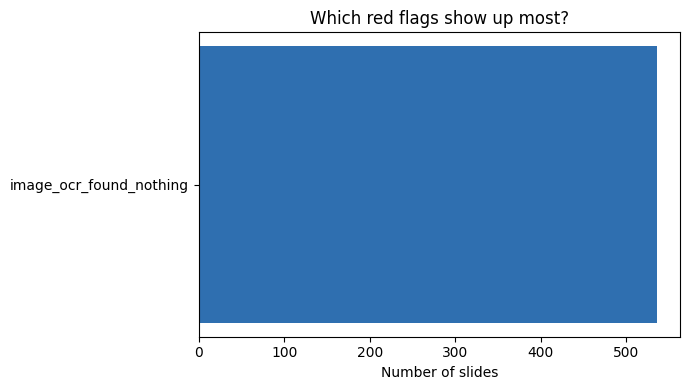

In [16]:
from collections import Counter

flag_counter = Counter()
for r in results:
    for f in r.flags:
        flag_counter[f.split("(")[0]] += 1   # collapse "image_no_ocr_text(x3)" into "image_no_ocr_text"

flag_df = pd.DataFrame(flag_counter.items(), columns=["flag", "count"]).sort_values("count", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(flag_df["flag"], flag_df["count"], color="#2f6fb0")
plt.xlabel("Number of slides")
plt.title("Which red flags show up most?")
plt.tight_layout()
plt.show()

## Step 5 — Chart: text length distribution

Slides with very little extracted text (far left of this chart) are your near-empty flags.
This helps you sanity-check whether your `MIN_CHARS_PER_SLIDE` threshold (in `extraction/qa/metrics.py`)
is set sensibly for your specific decks — adjust it there if you're seeing too many/few flags.

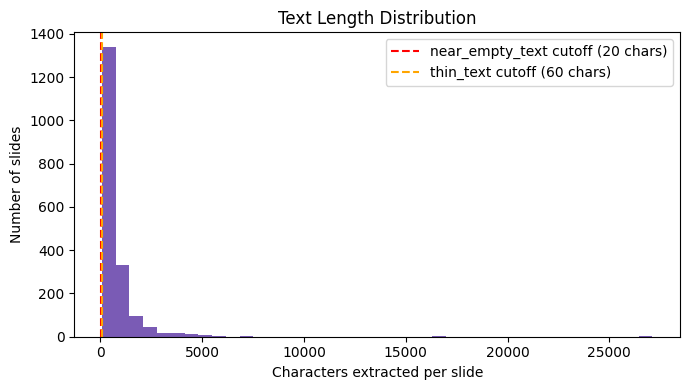

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(df["char_count"], bins=40, color="#7a5bb5")
plt.axvline(20, color="red", linestyle="--", label="near_empty_text cutoff (20 chars)")
plt.axvline(60, color="orange", linestyle="--", label="thin_text cutoff (60 chars)")
plt.xlabel("Characters extracted per slide")
plt.ylabel("Number of slides")
plt.title("Text Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Save the two review files

- `qa_report.csv` — every slide, worst-first (the full picture)
- `qa_review_sample.csv` — a short, manageable list: every flagged slide + a random sample of
  clean slides, meant for you to actually open and manually check by eye

In [18]:
write_report_csv(results, "qa_report.csv")

sample = build_review_sample(results, random_sample_size=30, flagged_cap=100)
sample_df = pd.DataFrame([{
    "document_id": r.document_id,
    "page_number": r.page_number,
    "risk_score": r.risk_score,
    "flags": "; ".join(r.flags),
    "reason": "FLAGGED" if r.risk_score > 0 else "RANDOM_SAMPLE",
} for r in sample])
sample_df.to_csv("qa_review_sample.csv", index=False)

print(f"Saved qa_report.csv ({len(df)} rows)")
print(f"Saved qa_review_sample.csv ({len(sample_df)} rows) — this is your manual review list")
sample_df

Saved qa_report.csv (1885 rows)
Saved qa_review_sample.csv (130 rows) — this is your manual review list


,document_id,page_number,risk_score,flags,reason
0,ARDC_Pidapalooza_Simons_Duncan_2020,1,3,image_ocr_found_nothing(x1),FLAGGED
1,ARDC_Pidapalooza_Simons_Duncan_2020,6,3,image_ocr_found_nothing(x1),FLAGGED
2,magCEvNS2018_mahapatra-rupak,2,3,image_ocr_found_nothing(x3),FLAGGED
3,magCEvNS2018_mahapatra-rupak,3,3,image_ocr_found_nothing(x3),FLAGGED
4,magCEvNS2018_mahapatra-rupak,5,3,image_ocr_found_nothing(x1),FLAGGED
...,...,...,...,...,...
125,1. Introduction to deep learning,26,0,,RANDOM_SAMPLE
126,NADDI 4-5,18,0,,RANDOM_SAMPLE
127,OS_4_PhD_2019,28,0,,RANDOM_SAMPLE
128,Bösmann EKC2023,15,0,,RANDOM_SAMPLE


## Step 7 — Manually inspect one flagged slide

Pick any `document_id` + `page_number` from the review sample above and look at its
full extracted content side by side — this is where you actually catch problems the
automated checks can't see (e.g. wrong numbers that still "look" like normal text).

In [19]:
import json

def inspect_slide(document_id: str, page_number: int, output_dir: str = OUTPUT_DIR):
    path = Path(output_dir) / f"{document_id}.json"
    with open(path) as f:
        doc = json.load(f)
    page = next(p for p in doc["pages"] if p["page_number"] == page_number)
    print(f"--- {document_id} | slide {page_number} ---\n")
    print("Reconstructed text:\n", page.get("reconstructed_text", "(empty)"), "\n")
    print(f"Objects ({len(page['objects'])}):")
    for obj in page["objects"]:
        print(f"  [{obj['type']}] {obj.get('text') or obj.get('rows') or obj.get('categories') or '(no content)'}")

# EXAMPLE — replace with a real row from sample_df above
# inspect_slide(document_id="pharma_dashboards", page_number=2)

## Recap

- **Green pie slice** = looks fine automatically
- **Orange pie slice** = needs a human look — start with the top rows of `df` above
- **`qa_review_sample.csv`** is your actual to-do list — open it, go row by row, use `inspect_slide()` on anything unclear
- If you're seeing too many false-alarm flags, adjust the thresholds in `extraction/qa/metrics.py` (`MIN_CHARS_PER_SLIDE`, `LOW_CHARS_PER_SLIDE`, `HIGH_SHAPE_RATIO`) and re-run this notebook

In [20]:
import extraction.qa.metrics as m
print(m.__file__)

/Users/rohit/Documents/Git/Enterprise_RAG_Pipeline/src/extraction/qa/metrics.py
